# Sellside Hawk/Dove Label Predictiveness — Intraday Front-End SOFR Futures Around Fed Speeches

**Hypothesis**: If sellside hawk/dove labels are informationally correct, the market should systematically
misprice front-end rate expectations around speeches. Hawks → rates higher (pay fixed / short SFR),
Doves → rates lower (receive fixed / long SFR).

**Signal**: JPM NLP hawk/dove scores (`trailing_5_avg`), bucketed to [-2, +2] for sizing.

In [18]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, r"C:\Users\chris\clee\ARBS")

import datetime
import pytz
import numpy as np
import pandas as pd
from collections import defaultdict

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use("ggplot")
params = {
    "legend.fontsize": "x-large",
    "figure.figsize": (14, 8),
    "axes.labelsize": "x-large",
    "axes.titlesize": "x-large",
    "xtick.labelsize": "x-large",
    "ytick.labelsize": "x-large",
}
pylab.rcParams.update(params)

import QuantLib as ql
import rateslib as rl

NYC_tz = pytz.timezone("America/New_York")

# ===================== CONFIGURABLE PARAMETERS =====================
# --- Entry/exit timing (change these to experiment) ---
# ENTRY_OFFSET = datetime.timedelta(hours=1)
ENTRY_OFFSET = datetime.timedelta(minutes=45)
EXIT_OFFSET  = datetime.timedelta(minutes=180)

# --- Instrument ---
CURVE = "USD-SOFR-1D-Q12STIRT"
TENOR = "IMM_3xIMM_4"

# --- Position sizing ---
BASE_BPV = 100_000  # DV01-equivalent per unit of |bucket| = 1

# --- JPM score config ---
SCORE_METRIC = "trailing_5_avg"  # or "rolling_6m_avg"

def score_to_bucket(score: float) -> int:
    """Map continuous JPM hawk/dove score to discrete [-2, -1, 0, +1, +2].
    Positive = hawk, negative = dove, 0 = neutral (no trade)."""
    if pd.isna(score):
        return 0
    if score >= 20:
        return 2   # strong hawk
    if score >= 10:
        return 1   # lean hawk
    if score > -10:
        return 0   # neutral → skip
    if score > -20:
        return -1  # lean dove
    return -2      # strong dove

# --- Manual score overrides for speakers not in JPM CSV ---
# These are static bucket assignments (not continuous scores).
# Use when a speaker has no JPM NLP history but you have a view.
MANUAL_SCORE_OVERRIDES = {
    "Miran": -1,  # Stephen Miran (CEA Chair) — uber dove but expected/discount b/c hes politcal
    # "Paulson": 0,  # uncomment and set if desired
}

# --- Market hours filter (ET) ---
EARLIEST_SPEECH = datetime.time(7, 0)
LATEST_SPEECH   = datetime.time(17, 0)

# --- FOMC blackout (days before/after meeting to exclude) ---
BLACKOUT_BD = 1

# --- MDP source ---
MDP_SOURCE = "BARCHART_STIRF-RL"

# --- Backtest date range ---
BT_START = "2021-01-01"
BT_END   = "2026-06-24"

print("Config loaded.")
print(f"Manual overrides: {MANUAL_SCORE_OVERRIDES}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Config loaded.
Manual overrides: {'Miran': -1}


## 1. Fetch Fed Speaker Schedule & Load JPM Hawk/Dove Scores

In [19]:
from RVUtils.forex_factory_calendar import ForexFactoryCalendarFetcher, ForexFactoryTheme

fetcher = ForexFactoryCalendarFetcher()
fed_speak_df = fetcher.fetch_range(
    BT_START,
    BT_END,
    themes=[ForexFactoryTheme.FED_SPEAKERS],
    show_tqdm=True,
    bulk_chunk_weeks=52,
)
print(f"Total Fed speech events from ForexFactory: {len(fed_speak_df)}")
fed_speak_df[["Date", "TimestampNYC", "Title", "Impact"]].head(10)

Fetching missing Forex Factory weeks: 0it [00:00, ?it/s]


Total Fed speech events from ForexFactory: 1477


,Date,TimestampNYC,Title,Impact
0,2021-01-04,2021-01-04 10:00:00-05:00,FOMC Member Evans Speaks,low
1,2021-01-04,2021-01-04 10:00:00-05:00,FOMC Member Bostic Speaks,low
2,2021-01-05,2021-01-05 15:45:00-05:00,FOMC Member Evans Speaks,low
3,2021-01-07,2021-01-07 13:00:00-05:00,FOMC Member Evans Speaks,low
4,2021-01-08,2021-01-08 11:00:00-05:00,FOMC Member Clarida Speaks,low
5,2021-01-11,2021-01-11 12:00:00-05:00,FOMC Member Bostic Speaks,low
6,2021-01-12,2021-01-12 09:35:00-05:00,FOMC Member Brainard Speaks,low
7,2021-01-13,2021-01-13 13:00:00-05:00,FOMC Member Brainard Speaks,low
8,2021-01-13,2021-01-13 15:00:00-05:00,FOMC Member Clarida Speaks,low
9,2021-01-14,2021-01-14 12:30:00-05:00,FOMC Member Powell Speaks,high


In [20]:
# Load JPM hawk/dove scores
jpm_scores = pd.read_csv(
    r"C:\Users\chris\clee\project-oasis\private\jpm_research\fed_speak_nlp\fed_hawk_dove_scores.csv"
)
jpm_scores["date"] = pd.to_datetime(jpm_scores["date"]).dt.date
jpm_scores = jpm_scores.sort_values(["speaker", "date"]).reset_index(drop=True)

KNOWN_SPEAKERS = sorted(jpm_scores["speaker"].unique())
print(f"JPM speakers ({len(KNOWN_SPEAKERS)}): {KNOWN_SPEAKERS}")
print(f"JPM score date range: {jpm_scores['date'].min()} → {jpm_scores['date'].max()}")
print(f"JPM score range ({SCORE_METRIC}): [{jpm_scores[SCORE_METRIC].min()}, {jpm_scores[SCORE_METRIC].max()}]")

JPM speakers (23): ['Barkin', 'Barr', 'Bostic', 'Bowman', 'Brainard', 'Collins', 'Cook', 'Daly', 'George', 'Goolsbee', 'Hammack', 'Harker', 'Jefferson', 'Kashkari', 'Kugler', 'Logan', 'Mester', 'Musalem', 'Powell', 'Schmid', 'Waller', 'Warsh', 'Williams']
JPM score date range: 2008-11-06 → 2026-06-17
JPM score range (trailing_5_avg): [-34, 55]


## 2. Match Events to Speakers, Assign Scores, Filter

In [21]:
import re


# --- Speaker extraction from ForexFactory title ---
def extract_speaker(title: str) -> str:
    """Extract speaker last name from ForexFactory title.
    'FOMC Member Cook Speaks' → 'Cook'
    'Fed Chair Powell Speaks' → 'Powell'
    """
    cleaned = re.sub(r"\b(Speaks?|Testifies|Testimony)\b", "", title).strip()
    parts = cleaned.split()
    return parts[-1] if parts else ""


# --- Score lookup: most recent JPM score STRICTLY BEFORE the speech date ---
# IMPORTANT: trailing_5_avg on date X includes speech X's own score (from JPM NLP).
# To avoid look-ahead bias, we use scores from BEFORE the speech date (strict <).
_speaker_score_cache = {}
for speaker, grp in jpm_scores.groupby("speaker"):
    grp_sorted = grp.sort_values("date")
    _speaker_score_cache[speaker] = (
        grp_sorted["date"].values,  # np.array of dates
        grp_sorted[SCORE_METRIC].values,  # np.array of scores
    )


def get_speaker_score(speaker: str, as_of: datetime.date) -> float:
    """Return the most recent JPM score for `speaker` STRICTLY BEFORE `as_of`.

    Uses strict < (not <=) to prevent look-ahead bias:
    the trailing_5_avg on date X includes speech X's own hawk_dove_score,
    which is only available after the speech occurs.
    """
    if speaker not in _speaker_score_cache:
        return np.nan
    dates, scores = _speaker_score_cache[speaker]
    as_of_np = np.datetime64(as_of)
    mask = dates < as_of_np  # STRICT less-than: no look-ahead
    if not mask.any():
        return np.nan
    return float(scores[mask][-1])


def get_bucket_for_speaker(speaker: str, speech_date: datetime.date) -> int:
    """Get the hawk/dove bucket for a speaker, checking manual overrides first."""
    if speaker in MANUAL_SCORE_OVERRIDES:
        return MANUAL_SCORE_OVERRIDES[speaker]
    raw_score = get_speaker_score(speaker, speech_date)
    return score_to_bucket(raw_score)


# --- FOMC meeting dates (for blackout filtering) ---
FOMC_DATES = [
	# 2020
    datetime.date(2020, 1, 29),
    datetime.date(2020, 3, 15),   # emergency Sun cut to 0–0.25%; scheduled Mar 17–18 mtg cancelled
    datetime.date(2020, 4, 29),
    datetime.date(2020, 6, 10),
    datetime.date(2020, 7, 29),
    datetime.date(2020, 9, 16),
    datetime.date(2020, 11, 5),
    datetime.date(2020, 12, 16),
    # 2021
    datetime.date(2021, 1, 27),
    datetime.date(2021, 3, 17),
    datetime.date(2021, 4, 28),
    datetime.date(2021, 6, 16),
    datetime.date(2021, 7, 28),
    datetime.date(2021, 9, 22),
    datetime.date(2021, 11, 3),
    datetime.date(2021, 12, 15),
    # 2022
    datetime.date(2022, 1, 26),
    datetime.date(2022, 3, 16),
    datetime.date(2022, 5, 4),
    datetime.date(2022, 6, 15),
    datetime.date(2022, 7, 27),
    datetime.date(2022, 9, 21),
    datetime.date(2022, 11, 2),
    datetime.date(2022, 12, 14),

    # 2023
    datetime.date(2023, 2, 1),
    datetime.date(2023, 3, 22),
    datetime.date(2023, 5, 3),
    datetime.date(2023, 6, 14),
    datetime.date(2023, 7, 26),
    datetime.date(2023, 9, 20),
    datetime.date(2023, 11, 1),
    datetime.date(2023, 12, 13),
    # 2024
    datetime.date(2024, 1, 31),
    datetime.date(2024, 3, 20),
    datetime.date(2024, 5, 1),
    datetime.date(2024, 6, 12),
    datetime.date(2024, 7, 31),
    datetime.date(2024, 9, 18),
    datetime.date(2024, 11, 7),
    datetime.date(2024, 12, 18),
    # 2025
    datetime.date(2025, 1, 29),
    datetime.date(2025, 3, 19),
    datetime.date(2025, 5, 7),
    datetime.date(2025, 6, 18),
    datetime.date(2025, 7, 30),
    datetime.date(2025, 9, 17),
    datetime.date(2025, 10, 29),
    datetime.date(2025, 12, 10),
    # 2026
    datetime.date(2026, 1, 28),
    datetime.date(2026, 3, 18),
    datetime.date(2026, 3, 18),
    datetime.date(2026, 4, 29),
    datetime.date(2026, 6, 17),
]

ql_cal = ql.UnitedStates(ql.UnitedStates.GovernmentBond)


def is_in_blackout(event_date: datetime.date) -> bool:
    """Check if event_date falls within BLACKOUT_BD business days of any FOMC meeting."""
    for fomc in FOMC_DATES:
        start_ql = ql.Date(fomc.day, fomc.month, fomc.year)
        lo = ql_cal.advance(start_ql, ql.Period(-BLACKOUT_BD, ql.Days), ql.Preceding)
        hi = ql_cal.advance(start_ql, ql.Period(BLACKOUT_BD, ql.Days), ql.Following)
        lo_date = datetime.date(lo.year(), lo.month(), lo.dayOfMonth())
        hi_date = datetime.date(hi.year(), hi.month(), hi.dayOfMonth())
        if lo_date <= event_date <= hi_date:
            return True
    return False


def _cap_exit_to_valid_trading_date(exit_ts, entry_ts):
    """Cap exit timestamp so its trading date stays on a business day.

    The BARCHART_STIRF curve builder maps evening timestamps to the NEXT calendar
    day. If that's a weekend/holiday, the curve fetch fails and the position is
    orphaned (popped from portfolio but never logged). We cap at 17:00 ET on the
    entry date to avoid this.
    """
    exit_date = exit_ts.date()
    exit_ql = ql.Date(exit_date.day, exit_date.month, exit_date.year)

    # If exit time is >= 17:00 ET, the curve builder may roll to next day
    if exit_ts.hour >= 17:
        return exit_ts.replace(hour=16, minute=59, second=0, microsecond=0)

    if not ql_cal.isBusinessDay(exit_ql):
        return entry_ts.replace(hour=16, minute=59, second=0, microsecond=0)

    return exit_ts


# --- Eligible speakers = JPM CSV speakers + manual overrides ---
ELIGIBLE_SPEAKERS = set(KNOWN_SPEAKERS) | set(MANUAL_SCORE_OVERRIDES.keys())

# --- Build trade events ---
trade_events = []
excluded = defaultdict(int)

for _, row in fed_speak_df.iterrows():
    title = row["Title"]
    speaker = extract_speaker(title)

    # Must be an eligible speaker (JPM CSV or manual override)
    if speaker not in ELIGIBLE_SPEAKERS:
        excluded["unknown_speaker"] += 1
        continue

    ts_nyc = row["TimestampNYC"]
    if pd.isna(ts_nyc):
        excluded["no_timestamp"] += 1
        continue

    # Ensure timezone-aware
    if ts_nyc.tzinfo is None:
        ts_nyc = NYC_tz.localize(ts_nyc)

    speech_date = ts_nyc.date()
    speech_time = ts_nyc.time()

    # Market hours filter
    if speech_time < EARLIEST_SPEECH or speech_time > LATEST_SPEECH:
        excluded["outside_market_hours"] += 1
        continue

    # Blackout filter
    if is_in_blackout(speech_date):
        excluded["fomc_blackout"] += 1
        continue

    # Exclude press conferences
    if "press conference" in title.lower():
        excluded["press_conference"] += 1
        continue

    # Get bucket (checks manual overrides first, then JPM score with strict <)
    bucket = get_bucket_for_speaker(speaker, speech_date)
    raw_score = get_speaker_score(speaker, speech_date)  # for logging (NaN for overrides)

    # Skip neutral
    if bucket == 0:
        excluded["neutral_score"] += 1
        continue

    entry_ts = ts_nyc - ENTRY_OFFSET
    exit_ts = ts_nyc + EXIT_OFFSET

    # Ensure entry is on a business day
    entry_ql = ql.Date(entry_ts.day, entry_ts.month, entry_ts.year)
    if not ql_cal.isBusinessDay(entry_ql):
        excluded["entry_not_bday"] += 1
        continue

    # Cap exit to valid trading date (prevent orphaned positions)
    exit_ts = _cap_exit_to_valid_trading_date(exit_ts, entry_ts)

    trade_events.append(
        {
            "event_id": row.get("EventId", len(trade_events)),
            "speaker": speaker,
            "title": title,
            "speech_ts": ts_nyc,
            "entry_ts": entry_ts,
            "exit_ts": exit_ts,
            "raw_score": raw_score,
            "bucket": bucket,
            "bpv": -bucket * BASE_BPV,  # hawk (+bucket) → pay fixed (negative bpv)
            "tag": f"speech_{row.get('EventId', len(trade_events))}",
            "source": "override" if speaker in MANUAL_SCORE_OVERRIDES else "jpm",
        }
    )

print(f"\n--- Event Filtering Summary ---")
print(f"Total ForexFactory events: {len(fed_speak_df)}")
for reason, count in sorted(excluded.items(), key=lambda x: -x[1]):
    print(f"  Excluded ({reason}): {count}")
print(f"  → Tradeable events: {len(trade_events)}")

# Show override-sourced events
override_events = [e for e in trade_events if e["source"] == "override"]
if override_events:
    print(f"\n  Override-sourced events: {len(override_events)}")
    for e in override_events[:5]:
        print(f"    {e['speaker']:12s} bucket={e['bucket']:+d} {e['speech_ts'].date()}")

# Apply overlap / no-stacking rule (chronological, skip if prior trade window overlaps)
trade_events.sort(key=lambda e: e["entry_ts"])
filtered_events = []
last_exit = None
overlap_count = 0
for ev in trade_events:
    if last_exit is not None and ev["entry_ts"] < last_exit:
        overlap_count += 1
        continue
    filtered_events.append(ev)
    last_exit = ev["exit_ts"]

print(f"  Removed for overlap: {overlap_count}")
print(f"  → Final trade count: {len(filtered_events)}")
trade_events = filtered_events

# Summary table
events_df = pd.DataFrame(trade_events)
display(events_df[["speaker", "speech_ts", "entry_ts", "exit_ts", "raw_score", "bucket", "bpv", "source"]].tail(15))


--- Event Filtering Summary ---
Total ForexFactory events: 1477
  Excluded (neutral_score): 545
  Excluded (outside_market_hours): 174
  Excluded (unknown_speaker): 88
  Excluded (entry_not_bday): 19
  Excluded (fomc_blackout): 8
  → Tradeable events: 643

  Override-sourced events: 23
    Miran        bucket=-1 2025-09-22
    Miran        bucket=-1 2025-09-25
    Miran        bucket=-1 2025-10-03
    Miran        bucket=-1 2025-10-03
    Miran        bucket=-1 2025-10-07
  Removed for overlap: 170
  → Final trade count: 473


,speaker,speech_ts,entry_ts,exit_ts,raw_score,bucket,bpv,source
458,Miran,2026-04-16 10:35:00-04:00,2026-04-16 09:50:00-04:00,2026-04-16 13:35:00-04:00,NaN,-1,100000,override
459,Waller,2026-04-17 14:00:00-04:00,2026-04-17 13:15:00-04:00,2026-04-17 16:59:00-04:00,-22.0,-2,200000,jpm
460,Waller,2026-04-21 14:30:00-04:00,2026-04-21 13:45:00-04:00,2026-04-21 16:59:00-04:00,-25.0,-2,200000,jpm
461,Bowman,2026-05-05 10:00:00-04:00,2026-05-05 09:15:00-04:00,2026-05-05 13:00:00-04:00,-26.0,-2,200000,jpm
462,Musalem,2026-05-06 09:30:00-04:00,2026-05-06 08:45:00-04:00,2026-05-06 12:30:00-04:00,14.0,1,-100000,jpm
463,Hammack,2026-05-07 14:05:00-04:00,2026-05-07 13:20:00-04:00,2026-05-07 16:59:00-04:00,15.0,1,-100000,jpm
464,Goolsbee,2026-05-08 11:05:00-04:00,2026-05-08 10:20:00-04:00,2026-05-08 14:05:00-04:00,19.0,1,-100000,jpm
465,Goolsbee,2026-05-12 09:10:00-04:00,2026-05-12 08:25:00-04:00,2026-05-12 12:10:00-04:00,19.0,1,-100000,jpm
466,Goolsbee,2026-05-12 13:00:00-04:00,2026-05-12 12:15:00-04:00,2026-05-12 16:00:00-04:00,19.0,1,-100000,jpm
467,Schmid,2026-05-14 10:15:00-04:00,2026-05-14 09:30:00-04:00,2026-05-14 13:15:00-04:00,21.0,2,-200000,jpm


## 3. Build Triggers & Run QueryDrivenBacktest

In [22]:
from BT.data_handler import TimeGrid
from BT.query_actions import AddQueryAction, UnwindPositionsAction
from BT.query_engine import QueryDrivenBacktest
from BT.query_strategy import QueryStrategy
from BT.triggers import Trigger, FlowSignalTriggerRequirements
from BT.event import TriggerInfo

from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP
from Query.IRSwaps.IRSwapQuery import IRSwapQuery
from Query.IRSwaps.IRSwapValue import IRSwapValue

curve_mdp = IRSwapsMDP(source=MDP_SOURCE)

# --- Build lookup dicts for entry/exit timestamps ---
entry_event_map = {}  # {timestamp: event_dict}
exit_timestamp_set = set()

for ev in trade_events:
    entry_event_map[ev["entry_ts"]] = ev
    exit_timestamp_set.add(ev["exit_ts"])

# --- Build a sparse TimeGrid with only entry + exit timestamps ---
all_timestamps = sorted(set(ev["entry_ts"] for ev in trade_events) | set(ev["exit_ts"] for ev in trade_events))
tg = TimeGrid(all_timestamps)
print(f"TimeGrid: {len(all_timestamps)} timestamps ({all_timestamps[0]} → {all_timestamps[-1]})")


# --- Exit trigger (evaluated first → unwind before new entry at same step) ---
def exit_signal_fn(state, backtest):
    return state in exit_timestamp_set


exit_trigger = Trigger(
    trigger_requirements=FlowSignalTriggerRequirements(signal_fn=exit_signal_fn),
    actions=[UnwindPositionsAction(match_all=True, fee=0.0)],
)

# --- Entry triggers (one per event, with no-stacking guard) ---
entry_triggers = []
for ev in trade_events:
    _ts = ev["entry_ts"]
    _query = IRSwapQuery(
        curve=CURVE,
        tenor=TENOR,
        value=IRSwapValue.NPV,
        structure_kwargs={"bpv": ev["bpv"]},
        tags=(ev["tag"],),
        meta={"speaker": ev["speaker"], "bucket": ev["bucket"], "raw_score": ev["raw_score"]},
    )

    # Closure: capture _ts and _query per-event
    def _make_signal(ts):
        def signal_fn(state, backtest):
            if state != ts:
                return False
            # No stacking: skip if position already open
            if len(backtest.portfolio.positions) > 0:
                return False
            return True

        return signal_fn

    entry_triggers.append(
        Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_make_signal(_ts)),
            actions=[AddQueryAction(query=_query)],
        )
    )

# --- Assemble strategy: exit first, then entries ---
all_triggers = [exit_trigger] + entry_triggers
strategy = QueryStrategy(name="Fed Hawk/Dove Intraday SFR", triggers=all_triggers)

print(f"Triggers: 1 exit + {len(entry_triggers)} entries = {len(all_triggers)} total")

# --- Run backtest ---
bt = QueryDrivenBacktest(
    time_grid=tg,
    mdp=curve_mdp,
    strategy=strategy,
    show_progress=True,
    progress_desc="Fed Hawk/Dove Backtest",
)
bt.run()
print(f"\nBacktest complete. Trades executed: {len(bt.portfolio.trades_log)}")

TimeGrid: 940 timestamps (2021-03-30 11:15:00-04:00 → 2026-06-04 13:00:00-04:00)
Triggers: 1 exit + 473 entries = 474 total


Fed Hawk/Dove Backtest: 100%|██████████| 940/940 [00:36<00:00, 26.08step/s]


Backtest complete. Trades executed: 467


## 4. Core Performance Metrics

  Fed Hawk/Dove Intraday SR3 Backtest — Summary
  Entry: T-0:45:00, Exit: T+3:00:00
  Contract: IMM_3xIMM_4 on USD-SOFR-1D-Q12STIRT
  Score metric: trailing_5_avg
  Trades:          467
  Cumulative P&L:  $28,415,126
  Avg P&L/trade:   $60,846
  Std P&L/trade:   $572,195
  Hit Rate:        57.8%
  Sharpe Ratio:    1.01
  Max Drawdown:    $-6,290,858
  Trades/Year:     90.2


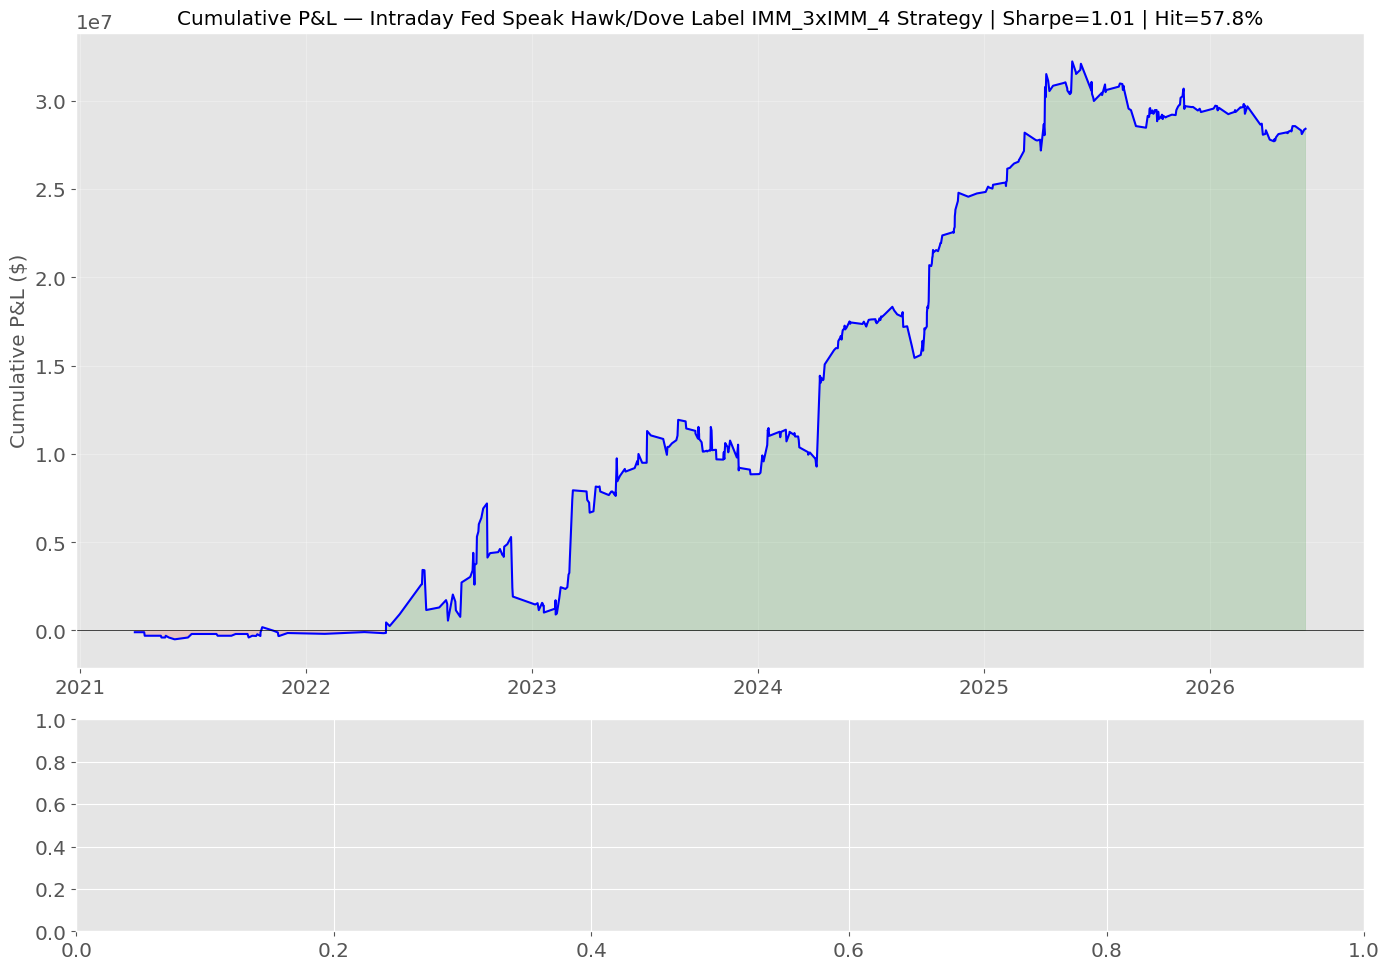

In [23]:
# --- Extract per-trade results from closed_positions_log ---
closed = pd.DataFrame(bt.portfolio.closed_positions_log)

if closed.empty:
    print("WARNING: No trades were closed. Check curve data availability.")
else:
    # Enrich with event metadata from source_query
    closed["speaker"] = closed["source_query"].apply(lambda q: q.meta.get("speaker", ""))
    closed["bucket"] = closed["source_query"].apply(lambda q: q.meta.get("bucket", 0))
    closed["raw_score"] = closed["source_query"].apply(lambda q: q.meta.get("raw_score", 0))
    closed["bpv"] = closed["source_query"].apply(lambda q: q.structure_kwargs.get("bpv", 0))
    closed["direction"] = closed["bucket"].apply(lambda b: "hawk" if b > 0 else "dove")
    closed["opened_at"] = pd.to_datetime(closed["opened_at"])
    closed["closed_at"] = pd.to_datetime(closed["closed_at"])
    closed["year"] = closed["opened_at"].dt.year
    closed["profitable"] = closed["realized_pnl"] > 0

    # --- Core metrics ---
    n_trades = len(closed)
    cum_pnl = closed["realized_pnl"].sum()
    hit_rate = closed["profitable"].mean()
    avg_pnl = closed["realized_pnl"].mean()
    std_pnl = closed["realized_pnl"].std()

    # Sharpe: annualize by sqrt(trades/year)
    years = (closed["opened_at"].max() - closed["opened_at"].min()).days / 365.25
    trades_per_year = n_trades / years if years > 0 else n_trades
    sharpe = (avg_pnl / std_pnl) * np.sqrt(trades_per_year) if std_pnl > 0 else 0.0

    # Max drawdown on cumulative P&L
    cum_series = closed["realized_pnl"].cumsum()
    running_max = cum_series.cummax()
    drawdown = cum_series - running_max
    max_dd = drawdown.min()

    print("=" * 60)
    print(f"  Fed Hawk/Dove Intraday SR3 Backtest — Summary")
    print(f"  Entry: T-{ENTRY_OFFSET}, Exit: T+{EXIT_OFFSET}")
    print(f"  Contract: {TENOR} on {CURVE}")
    print(f"  Score metric: {SCORE_METRIC}")
    print("=" * 60)
    print(f"  Trades:          {n_trades}")
    print(f"  Cumulative P&L:  ${cum_pnl:,.0f}")
    print(f"  Avg P&L/trade:   ${avg_pnl:,.0f}")
    print(f"  Std P&L/trade:   ${std_pnl:,.0f}")
    print(f"  Hit Rate:        {hit_rate:.1%}")
    print(f"  Sharpe Ratio:    {sharpe:.2f}")
    print(f"  Max Drawdown:    ${max_dd:,.0f}")
    print(f"  Trades/Year:     {trades_per_year:.1f}")
    print("=" * 60)

    # --- Cumulative P&L plot ---
    fig, axes = plt.subplots(2, 1, figsize=(14, 10), gridspec_kw={"height_ratios": [3, 1]})

    ax1 = axes[0]
    ax1.plot(closed["opened_at"].values, cum_series.values, "b-", lw=1.5)
    ax1.fill_between(closed["opened_at"].values, 0, cum_series.values,
                     where=cum_series.values >= 0, alpha=0.15, color="green")
    ax1.fill_between(closed["opened_at"].values, 0, cum_series.values,
                     where=cum_series.values < 0, alpha=0.15, color="red")
    ax1.axhline(0, color="k", lw=0.5)
    ax1.set_title(f"Cumulative P&L — Intraday Fed Speak Hawk/Dove Label {TENOR} Strategy | Sharpe={sharpe:.2f} | Hit={hit_rate:.1%}")
    ax1.set_ylabel("Cumulative P&L ($)")
    ax1.grid(True, alpha=0.3)

    # ax2 = axes[1]
    # colors = ["green" if x > 0 else "red" for x in closed["realized_pnl"].values]
    # ax2.bar(closed["opened_at"].values, closed["realized_pnl"].values, color=colors, alpha=0.6, width=2)
    # ax2.axhline(0, color="k", lw=0.5)
    # ax2.set_ylabel("Per-Trade P&L ($)")
    # ax2.set_xlabel("Date")
    # ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## 5. P&L by Speaker Attribution

,trades,total_pnl,avg_pnl,hit_rate,avg_score
speaker,,,,,
Powell,31,"$4,482,434","$144,595",51.6%,30.9
Logan,16,"$3,518,968","$219,935",56.2%,17.8
Williams,40,"$3,427,800","$85,695",52.5%,24.8
Musalem,20,"$3,136,614","$156,831",70.0%,19.1
Bowman,59,"$3,036,148","$51,460",49.2%,10.2
Bostic,58,"$2,698,406","$46,524",53.4%,-7.3
Barkin,50,"$1,797,747","$35,955",50.0%,14.2
Collins,5,"$1,561,000","$312,200",80.0%,13.8
Waller,38,"$1,198,623","$31,543",60.5%,4.3


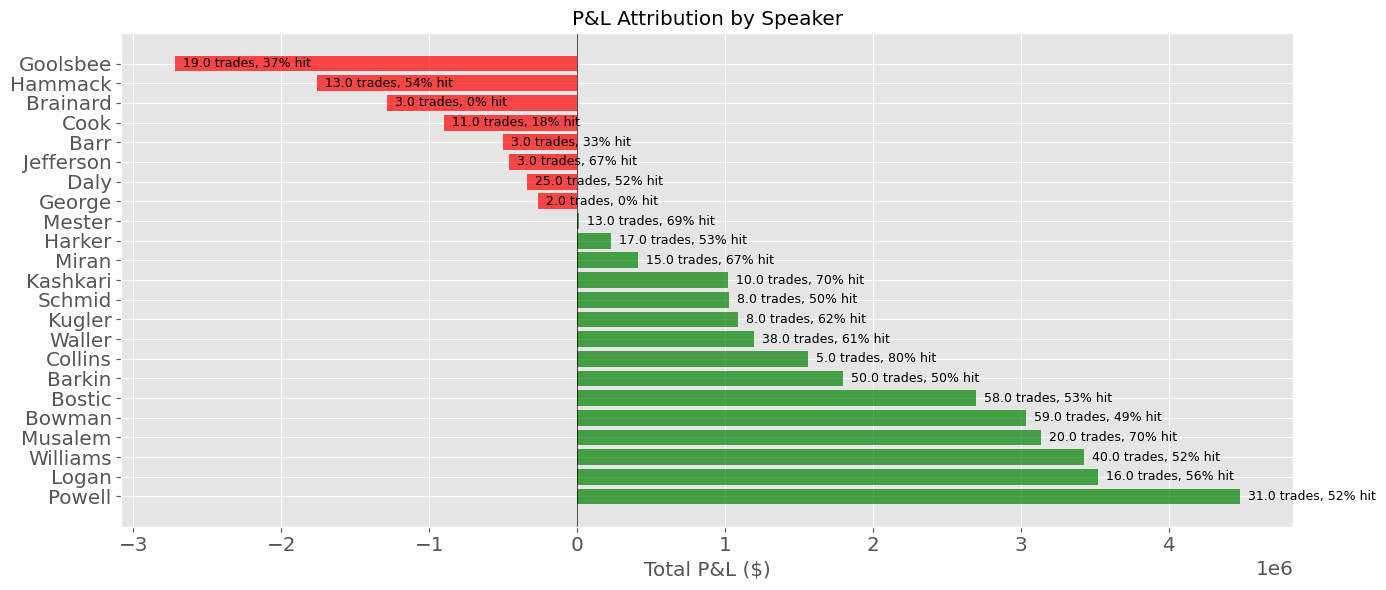

In [10]:
if not closed.empty:
    speaker_stats = (
        closed.groupby("speaker")
        .agg(
            trades=("realized_pnl", "count"),
            total_pnl=("realized_pnl", "sum"),
            avg_pnl=("realized_pnl", "mean"),
            hit_rate=("profitable", "mean"),
            avg_score=("raw_score", "mean"),
        )
        .sort_values("total_pnl", ascending=False)
    )
    display(speaker_stats.style.format({
        "total_pnl": "${:,.0f}", "avg_pnl": "${:,.0f}",
        "hit_rate": "{:.1%}", "avg_score": "{:.1f}",
    }))

    # Bar chart: P&L by speaker
    fig, ax = plt.subplots(figsize=(14, 6))
    colors = ["green" if x > 0 else "red" for x in speaker_stats["total_pnl"]]
    ax.barh(speaker_stats.index, speaker_stats["total_pnl"], color=colors, alpha=0.7)
    ax.set_xlabel("Total P&L ($)")
    ax.set_title("P&L Attribution by Speaker")
    ax.axvline(0, color="k", lw=0.5)
    for i, (speaker, row) in enumerate(speaker_stats.iterrows()):
        ax.text(
            row["total_pnl"], i,
            f"  {row['trades']} trades, {row['hit_rate']:.0%} hit",
            va="center", fontsize=9,
        )
    plt.tight_layout()
    plt.show()

## 6. P&L by Score Bucket & Hawk vs Dove Asymmetry

In [11]:
if not closed.empty:
    # --- By score bucket ---
    bucket_stats = (
        closed.groupby("bucket")
        .agg(
            trades=("realized_pnl", "count"),
            total_pnl=("realized_pnl", "sum"),
            avg_pnl=("realized_pnl", "mean"),
            hit_rate=("profitable", "mean"),
        )
        .sort_index()
    )
    print("P&L by Score Bucket (|Si|):")
    display(bucket_stats.style.format({
        "total_pnl": "${:,.0f}", "avg_pnl": "${:,.0f}", "hit_rate": "{:.1%}",
    }))

    # --- Hawk vs Dove asymmetry ---
    hawk_mask = closed["bucket"] > 0
    dove_mask = closed["bucket"] < 0

    print("\n--- Hawk vs Dove Asymmetry ---")
    for label, mask in [("Hawk (pay fixed)", hawk_mask), ("Dove (receive fixed)", dove_mask)]:
        sub = closed[mask]
        if len(sub) == 0:
            print(f"  {label}: no trades")
            continue
        print(f"  {label}:")
        print(f"    Trades: {len(sub)}, Total P&L: ${sub['realized_pnl'].sum():,.0f}, "
              f"Avg: ${sub['realized_pnl'].mean():,.0f}, Hit: {sub['profitable'].mean():.1%}")

    # --- By absolute bucket magnitude ---
    closed["abs_bucket"] = closed["bucket"].abs()
    abs_bucket_stats = (
        closed.groupby("abs_bucket")
        .agg(
            trades=("realized_pnl", "count"),
            total_pnl=("realized_pnl", "sum"),
            avg_pnl=("realized_pnl", "mean"),
            hit_rate=("profitable", "mean"),
        )
    )
    print("\nP&L by |Score Bucket| (conviction strength):")
    display(abs_bucket_stats.style.format({
        "total_pnl": "${:,.0f}", "avg_pnl": "${:,.0f}", "hit_rate": "{:.1%}",
    }))

P&L by Score Bucket (|Si|):


,trades,total_pnl,avg_pnl,hit_rate
bucket,,,,
-2,59,"$531,268","$9,005",47.5%
-1,29,"$33,394","$1,152",58.6%
1,219,"$8,123,657","$37,094",52.5%
2,160,"$11,720,151","$73,251",55.0%



--- Hawk vs Dove Asymmetry ---
  Hawk (pay fixed):
    Trades: 379, Total P&L: $19,843,808, Avg: $52,358, Hit: 53.6%
  Dove (receive fixed):
    Trades: 88, Total P&L: $564,662, Avg: $6,417, Hit: 51.1%

P&L by |Score Bucket| (conviction strength):


,trades,total_pnl,avg_pnl,hit_rate
abs_bucket,,,,
1,248,"$8,157,051","$32,891",53.2%
2,219,"$12,251,419","$55,943",53.0%


## 7. Calendar-Year Breakdown

Calendar-Year Breakdown:


,trades,total_pnl,avg_pnl,hit_rate,std_pnl,sharpe
year,,,,,,
2021,39,"$1,054,474","$27,038",46.2%,"$148,894",1.13
2022,49,"$602,989","$12,306",57.1%,"$828,259",0.10
2023,97,"$2,940,920","$30,319",44.3%,"$571,316",0.52
2024,121,"$13,240,641","$109,427",59.5%,"$459,461",2.62
2025,112,"$3,650,335","$32,592",52.7%,"$418,175",0.82
2026,49,"$-1,080,889","$-22,059",57.1%,"$179,260",-0.86


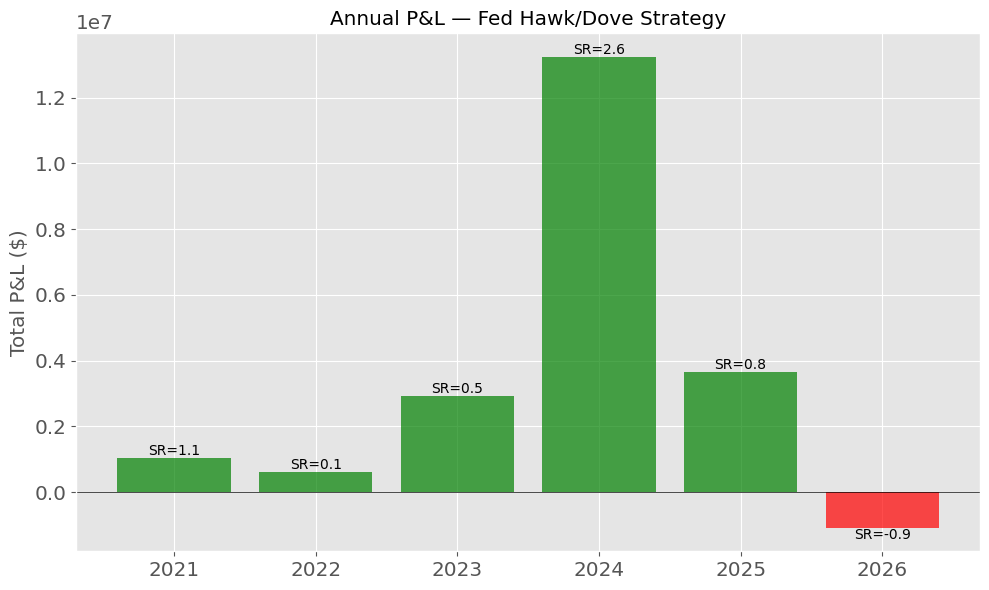

In [12]:
if not closed.empty:
    year_stats = (
        closed.groupby("year")
        .agg(
            trades=("realized_pnl", "count"),
            total_pnl=("realized_pnl", "sum"),
            avg_pnl=("realized_pnl", "mean"),
            hit_rate=("profitable", "mean"),
            std_pnl=("realized_pnl", "std"),
        )
    )
    year_stats["sharpe"] = (
        year_stats["avg_pnl"] / year_stats["std_pnl"]
    ) * np.sqrt(year_stats["trades"])

    print("Calendar-Year Breakdown:")
    display(year_stats.style.format({
        "total_pnl": "${:,.0f}", "avg_pnl": "${:,.0f}", "std_pnl": "${:,.0f}",
        "hit_rate": "{:.1%}", "sharpe": "{:.2f}",
    }))

    # Stacked bar: annual P&L
    fig, ax = plt.subplots(figsize=(10, 6))
    colors = ["green" if x > 0 else "red" for x in year_stats["total_pnl"]]
    ax.bar(year_stats.index.astype(str), year_stats["total_pnl"], color=colors, alpha=0.7)
    ax.set_ylabel("Total P&L ($)")
    ax.set_title("Annual P&L — Fed Hawk/Dove Strategy")
    ax.axhline(0, color="k", lw=0.5)
    for i, (yr, row) in enumerate(year_stats.iterrows()):
        ax.text(i, row["total_pnl"], f"SR={row['sharpe']:.1f}", ha="center",
                va="bottom" if row["total_pnl"] >= 0 else "top", fontsize=10)
    plt.tight_layout()
    plt.show()

## 8. Robustness Checks

### 8.1 Score Permutation Test (is the signal better than random labels?)

Permutation Test (1000 iterations)
  Realized Sharpe: 0.846
  Permuted Sharpe (mean): 0.012
  Permuted Sharpe (std):  0.431
  p-value (one-sided):    0.028
  SIGNIFICANT at 5%


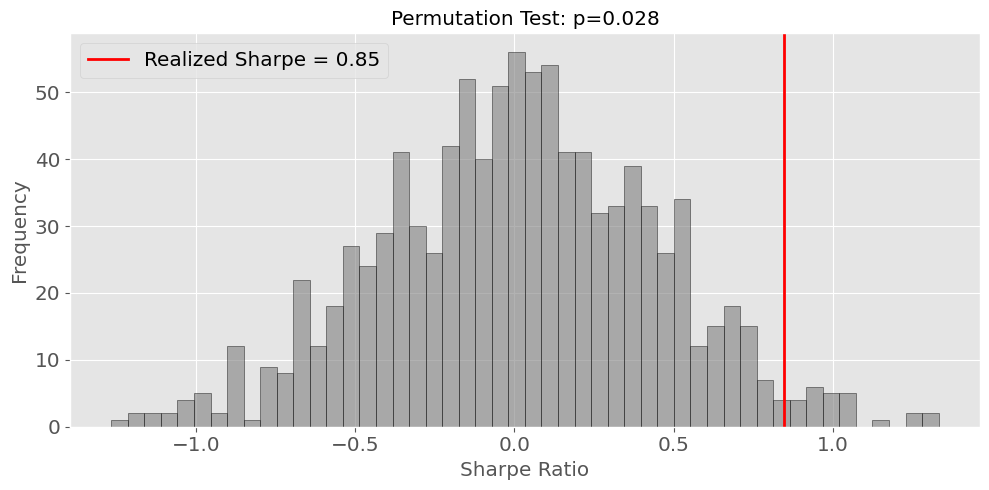

In [13]:
if not closed.empty:
    N_PERMUTATIONS = 1000
    rng = np.random.default_rng(42)

    # The realized P&L per trade is a function of (entry/exit prices) * (direction * size).
    # Under the null, we shuffle the bucket assignments across trades.
    # This preserves the entry/exit price moves but randomizes direction/size.
    #
    # We can approximate this by: for each permutation, randomly flip the sign of realized_pnl
    # for each trade (since shuffling direction is equivalent to random sign assignment).
    # This is a standard sign-flip permutation test.
    
    # Normalize P&L to per-unit-bpv for fair comparison (remove sizing effect)
    pnl_per_unit = closed["realized_pnl"].values / closed["bucket"].abs().values
    realized_sharpe = avg_pnl / std_pnl * np.sqrt(trades_per_year) if std_pnl > 0 else 0

    permuted_sharpes = []
    for _ in range(N_PERMUTATIONS):
        signs = rng.choice([-1, 1], size=len(pnl_per_unit))
        perm_pnl = closed["realized_pnl"].values * signs
        perm_avg = perm_pnl.mean()
        perm_std = perm_pnl.std()
        perm_sharpe = (perm_avg / perm_std * np.sqrt(trades_per_year)) if perm_std > 0 else 0
        permuted_sharpes.append(perm_sharpe)

    permuted_sharpes = np.array(permuted_sharpes)
    p_value = (permuted_sharpes >= realized_sharpe).mean()

    print(f"Permutation Test ({N_PERMUTATIONS} iterations)")
    print(f"  Realized Sharpe: {realized_sharpe:.3f}")
    print(f"  Permuted Sharpe (mean): {permuted_sharpes.mean():.3f}")
    print(f"  Permuted Sharpe (std):  {permuted_sharpes.std():.3f}")
    print(f"  p-value (one-sided):    {p_value:.3f}")
    print(f"  {'SIGNIFICANT at 5%' if p_value < 0.05 else 'NOT significant at 5%'}")

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.hist(permuted_sharpes, bins=50, alpha=0.6, color="gray", edgecolor="black")
    ax.axvline(realized_sharpe, color="red", lw=2, label=f"Realized Sharpe = {realized_sharpe:.2f}")
    ax.set_xlabel("Sharpe Ratio")
    ax.set_ylabel("Frequency")
    ax.set_title(f"Permutation Test: p={p_value:.3f}")
    ax.legend()
    plt.tight_layout()
    plt.show()

### 8.2 Subsample Stability (first half vs second half)

In [14]:
if not closed.empty:
    mid = len(closed) // 2
    halves = {"First Half": closed.iloc[:mid], "Second Half": closed.iloc[mid:]}

    print("Subsample Stability:")
    rows = []
    for name, sub in halves.items():
        sub_years = max((sub["opened_at"].max() - sub["opened_at"].min()).days / 365.25, 0.5)
        sub_tpy = len(sub) / sub_years
        sub_std = sub["realized_pnl"].std()
        sub_sharpe = (sub["realized_pnl"].mean() / sub_std * np.sqrt(sub_tpy)) if sub_std > 0 else 0
        rows.append({
            "Period": name,
            "Date Range": f"{sub['opened_at'].min().date()} → {sub['opened_at'].max().date()}",
            "Trades": len(sub),
            "Total P&L": sub["realized_pnl"].sum(),
            "Avg P&L": sub["realized_pnl"].mean(),
            "Hit Rate": sub["profitable"].mean(),
            "Sharpe": sub_sharpe,
        })
    display(pd.DataFrame(rows).style.format({
        "Total P&L": "${:,.0f}", "Avg P&L": "${:,.0f}",
        "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    }))

Subsample Stability:


,Period,Date Range,Trades,Total P&L,Avg P&L,Hit Rate,Sharpe
0,First Half,2021-03-30 → 2024-05-15,233,"$10,554,314","$45,297",49.4%,0.65
1,Second Half,2024-05-16 → 2026-06-04,234,"$9,854,156","$42,112",56.8%,1.27


### 8.3 Transaction Cost Sensitivity

In [15]:
if not closed.empty:
    cost_bps_levels = [0, 0.25, 0.5, 1.0, 2.0, 5.0]
    cost_rows = []

    for cost_bps in cost_bps_levels:
        # Round-trip cost in $ per trade = cost_bps * abs(bpv) / 10000 * 2 sides
        # Simpler: cost per trade = cost_bps * BASE_BPV (since bpv is per-unit)
        # Actually: cost = cost_bps * |bpv_used| where bpv_used = |bucket| * BASE_BPV
        cost_per_trade = closed["bucket"].abs() * BASE_BPV * cost_bps / 10_000
        adj_pnl = closed["realized_pnl"] - cost_per_trade
        adj_cum = adj_pnl.sum()
        adj_avg = adj_pnl.mean()
        adj_std = adj_pnl.std()
        adj_sharpe = (adj_avg / adj_std * np.sqrt(trades_per_year)) if adj_std > 0 else 0
        adj_hit = (adj_pnl > 0).mean()

        cost_rows.append({
            "Cost (bps RT)": cost_bps,
            "Cum P&L": adj_cum,
            "Avg P&L": adj_avg,
            "Hit Rate": adj_hit,
            "Sharpe": adj_sharpe,
        })

    cost_df = pd.DataFrame(cost_rows)
    print("Transaction Cost Sensitivity:")
    display(cost_df.style.format({
        "Cost (bps RT)": "{:.2f}",
        "Cum P&L": "${:,.0f}", "Avg P&L": "${:,.0f}",
        "Hit Rate": "{:.1%}", "Sharpe": "{:.2f}",
    }))

Transaction Cost Sensitivity:


,Cost (bps RT),Cum P&L,Avg P&L,Hit Rate,Sharpe
0,0.00,"$20,408,470","$43,701",53.1%,0.85
1,0.25,"$20,406,755","$43,698",50.3%,0.85
2,0.50,"$20,405,040","$43,694",50.3%,0.85
3,1.00,"$20,401,610","$43,687",50.3%,0.85
4,2.00,"$20,394,750","$43,672",50.3%,0.85
5,5.00,"$20,374,170","$43,628",50.3%,0.84


### 8.4 Entry/Exit Window Sensitivity Heatmap

Re-runs the backtest with different entry/exit offsets. This is the most computationally expensive robustness check — each cell in the grid requires a full backtest pass. To keep runtime manageable, we re-use the same MDP and re-price the same events with different timing windows.

Running 4x5 = 20 sensitivity backtests...


C:\Users\chris\clee\ARBS\MDP\STIRFutures\BARCHART\BarchartFetcher.py:698: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_slice["Date"] = pd.to_datetime(df_slice["Date"], errors="coerce")


  Entry T-120min, Exit T+60min: Sharpe=0.43, P&L=$10,974,667, Hit=52.0%, N=473
2022-09-30 18:15:00-04:00 maps to non-business trading date 2022-10-01 in the US government bond market calendar!
2023-04-21 18:35:00-04:00 maps to non-business trading date 2023-04-22 in the US government bond market calendar!
2024-01-19 18:15:00-05:00 maps to non-business trading date 2024-01-20 in the US government bond market calendar!
2024-03-22 18:00:00-04:00 maps to non-business trading date 2024-03-23 in the US government bond market calendar!
  Entry T-120min, Exit T+120min: Sharpe=0.29, P&L=$7,077,851, Hit=51.6%, N=448
2022-09-30 19:15:00-04:00 maps to non-business trading date 2022-10-01 in the US government bond market calendar!
2023-03-31 18:05:00-04:00 maps to non-business trading date 2023-04-01 in the US government bond market calendar!
2023-04-21 19:35:00-04:00 maps to non-business trading date 2023-04-22 in the US government bond market calendar!
2024-01-19 19:15:00-05:00 maps to non-busine

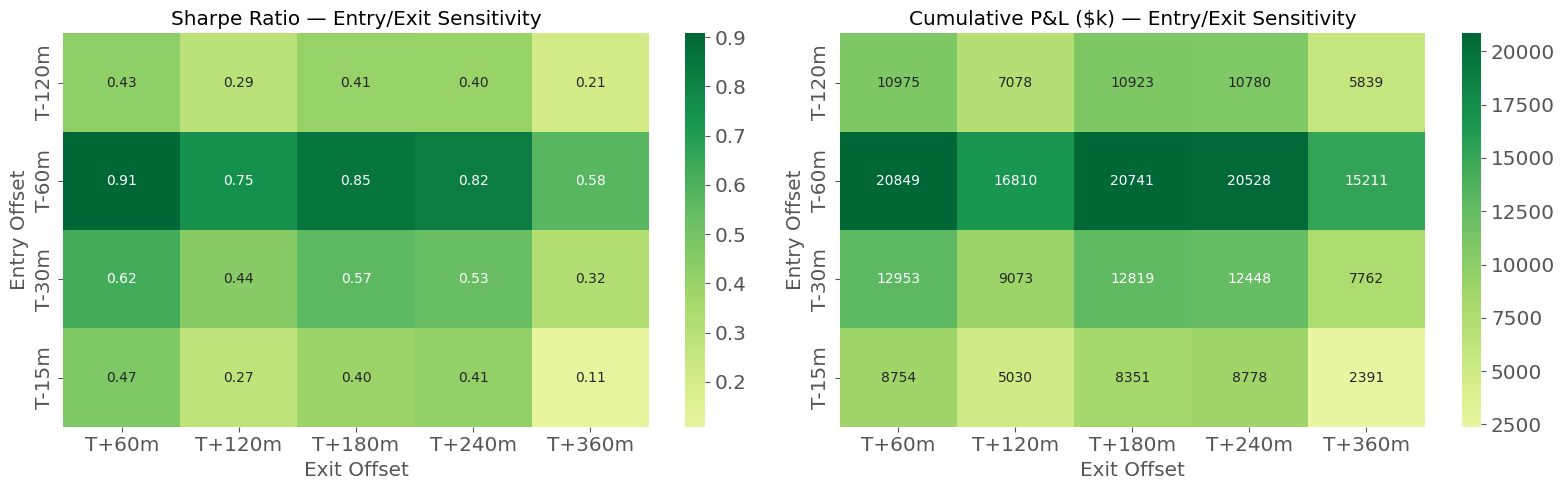

In [16]:
import seaborn as sns
from itertools import product as iterproduct

def run_backtest_for_offsets(events_base, entry_offset_min, exit_offset_min, mdp):
    """Re-run the backtest with different entry/exit offsets.
    Returns (sharpe, cum_pnl, hit_rate, n_trades) or None on failure."""
    entry_off = datetime.timedelta(minutes=entry_offset_min)
    exit_off = datetime.timedelta(minutes=exit_offset_min)

    # Rebuild events with new offsets
    new_events = []
    last_exit = None
    for ev in events_base:
        entry_ts = ev["speech_ts"] + entry_off
        exit_ts = ev["speech_ts"] + exit_off
        # No stacking
        if last_exit is not None and entry_ts < last_exit:
            continue
        new_events.append({**ev, "entry_ts": entry_ts, "exit_ts": exit_ts})
        last_exit = exit_ts

    if len(new_events) < 5:
        return None

    # Build triggers
    exit_ts_set = set(e["exit_ts"] for e in new_events)
    all_ts = sorted(set(e["entry_ts"] for e in new_events) | exit_ts_set)

    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt, _ets=exit_ts_set: s in _ets
        ),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)],
    )

    entry_trigs = []
    for ev in new_events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(
            curve=CURVE, tenor=TENOR, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]},
            tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "bucket": ev["bucket"], "raw_score": ev["raw_score"]},
        )
        def _mk(ts):
            def fn(s, bt):
                return s == ts and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)],
        ))

    strat = QueryStrategy(name="sens", triggers=[exit_trig] + entry_trigs)
    bt2 = QueryDrivenBacktest(time_grid=TimeGrid(all_ts), mdp=mdp, strategy=strat, show_progress=False)

    try:
        bt2.run()
    except Exception as e:
        print(f"  offset ({entry_offset_min}, {exit_offset_min}) failed: {e}")
        return None

    cl = pd.DataFrame(bt2.portfolio.closed_positions_log)
    if cl.empty:
        return None

    n = len(cl)
    cpnl = cl["realized_pnl"].sum()
    avg = cl["realized_pnl"].mean()
    std = cl["realized_pnl"].std()
    yrs = max((pd.to_datetime(cl["opened_at"]).max() - pd.to_datetime(cl["opened_at"]).min()).days / 365.25, 0.5)
    tpy = n / yrs
    sr = (avg / std * np.sqrt(tpy)) if std > 0 else 0
    hr = (cl["realized_pnl"] > 0).mean()
    return sr, cpnl, hr, n

# --- Grid search ---
ENTRY_OFFSETS_MIN = [-120, -60, -30, -15]
EXIT_OFFSETS_MIN = [60, 120, 180, 240, 360]

print(f"Running {len(ENTRY_OFFSETS_MIN)}x{len(EXIT_OFFSETS_MIN)} = {len(ENTRY_OFFSETS_MIN)*len(EXIT_OFFSETS_MIN)} sensitivity backtests...")

results_grid = {}
for eo, xo in iterproduct(ENTRY_OFFSETS_MIN, EXIT_OFFSETS_MIN):
    result = run_backtest_for_offsets(trade_events, eo, xo, curve_mdp)
    if result:
        results_grid[(eo, xo)] = result
        print(f"  Entry T{eo:+d}min, Exit T+{xo}min: Sharpe={result[0]:.2f}, P&L=${result[1]:,.0f}, Hit={result[2]:.1%}, N={result[3]}")

# --- Heatmap ---
if results_grid:
    sharpe_matrix = pd.DataFrame(
        index=[f"T{e:+d}m" for e in ENTRY_OFFSETS_MIN],
        columns=[f"T+{x}m" for x in EXIT_OFFSETS_MIN],
        dtype=float,
    )
    pnl_matrix = sharpe_matrix.copy()

    for (eo, xo), (sr, cpnl, hr, n) in results_grid.items():
        sharpe_matrix.loc[f"T{eo:+d}m", f"T+{xo}m"] = sr
        pnl_matrix.loc[f"T{eo:+d}m", f"T+{xo}m"] = cpnl

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    sns.heatmap(sharpe_matrix.astype(float), annot=True, fmt=".2f", cmap="RdYlGn",
                center=0, ax=axes[0])
    axes[0].set_title("Sharpe Ratio — Entry/Exit Sensitivity")
    axes[0].set_xlabel("Exit Offset")
    axes[0].set_ylabel("Entry Offset")

    sns.heatmap(pnl_matrix.astype(float) / 1000, annot=True, fmt=".0f", cmap="RdYlGn",
                center=0, ax=axes[1])
    axes[1].set_title("Cumulative P&L ($k) — Entry/Exit Sensitivity")
    axes[1].set_xlabel("Exit Offset")
    axes[1].set_ylabel("Entry Offset")

    plt.tight_layout()
    plt.show()

### 8.5 Contract Selection Sensitivity (1st through 4th deferred quarterly)

In [14]:
CONTRACT_TENORS = {
    "1st Quarterly (IMM_1xIMM_2)": "IMM_1xIMM_2",
    "2nd Quarterly (IMM_2xIMM_3)": "IMM_2xIMM_3",
    "3rd Quarterly (IMM_3xIMM_4)": "IMM_3xIMM_4",
    "4th Quarterly (IMM_4xIMM_5)": "IMM_4xIMM_5",
}

def run_backtest_for_tenor(events, tenor, mdp):
    """Run the baseline backtest with a different contract tenor."""
    exit_ts_set = set(e["exit_ts"] for e in events)
    all_ts = sorted(set(e["entry_ts"] for e in events) | exit_ts_set)

    exit_trig = Trigger(
        trigger_requirements=FlowSignalTriggerRequirements(
            signal_fn=lambda s, bt, _ets=exit_ts_set: s in _ets
        ),
        actions=[UnwindPositionsAction(match_all=True, fee=0.0)],
    )

    entry_trigs = []
    for ev in events:
        _ts = ev["entry_ts"]
        _q = IRSwapQuery(
            curve=CURVE, tenor=tenor, value=IRSwapValue.NPV,
            structure_kwargs={"bpv": ev["bpv"]},
            tags=(ev["tag"],),
            meta={"speaker": ev["speaker"], "bucket": ev["bucket"], "raw_score": ev["raw_score"]},
        )
        def _mk(ts):
            def fn(s, bt):
                return s == ts and len(bt.portfolio.positions) == 0
            return fn
        entry_trigs.append(Trigger(
            trigger_requirements=FlowSignalTriggerRequirements(signal_fn=_mk(_ts)),
            actions=[AddQueryAction(query=_q)],
        ))

    strat = QueryStrategy(name=f"tenor_{tenor}", triggers=[exit_trig] + entry_trigs)
    bt2 = QueryDrivenBacktest(time_grid=TimeGrid(all_ts), mdp=mdp, strategy=strat, show_progress=False)

    try:
        bt2.run()
    except Exception as e:
        print(f"  tenor {tenor} failed: {e}")
        return None

    cl = pd.DataFrame(bt2.portfolio.closed_positions_log)
    if cl.empty:
        return None

    n = len(cl)
    cpnl = cl["realized_pnl"].sum()
    avg = cl["realized_pnl"].mean()
    std = cl["realized_pnl"].std()
    yrs = max((pd.to_datetime(cl["opened_at"]).max() - pd.to_datetime(cl["opened_at"]).min()).days / 365.25, 0.5)
    tpy = n / yrs
    sr = (avg / std * np.sqrt(tpy)) if std > 0 else 0
    hr = (cl["realized_pnl"] > 0).mean()
    return {"Sharpe": sr, "Cum P&L": cpnl, "Hit Rate": hr, "Trades": n}

print("Contract selection sensitivity:")
tenor_rows = []
for label, tenor in CONTRACT_TENORS.items():
    print(f"  Running {label}...")
    result = run_backtest_for_tenor(trade_events, tenor, curve_mdp)
    if result:
        tenor_rows.append({"Contract": label, **result})
        print(f"    Sharpe={result['Sharpe']:.2f}, P&L=${result['Cum P&L']:,.0f}")

if tenor_rows:
    tenor_df = pd.DataFrame(tenor_rows)
    display(tenor_df.style.format({
        "Sharpe": "{:.2f}", "Cum P&L": "${:,.0f}", "Hit Rate": "{:.1%}",
    }))

Contract selection sensitivity:
  Running 1st Quarterly (IMM_1xIMM_2)...
    Sharpe=0.19, P&L=$2,149,363
  Running 2nd Quarterly (IMM_2xIMM_3)...
    Sharpe=0.89, P&L=$11,675,127
  Running 3rd Quarterly (IMM_3xIMM_4)...
    Sharpe=1.11, P&L=$17,357,806
  Running 4th Quarterly (IMM_4xIMM_5)...
    Sharpe=1.03, P&L=$17,398,602


,Contract,Sharpe,Cum P&L,Hit Rate,Trades
0,1st Quarterly (IMM_1xIMM_2),0.19,"$2,149,363",49.7%,308
1,2nd Quarterly (IMM_2xIMM_3),0.89,"$11,675,127",51.9%,308
2,3rd Quarterly (IMM_3xIMM_4),1.11,"$17,357,806",55.5%,308
3,4th Quarterly (IMM_4xIMM_5),1.03,"$17,398,602",55.5%,308


## 9. Full Trade Log

In [15]:
if not closed.empty:
    trade_log = closed[[
        "opened_at", "closed_at", "speaker", "direction", "bucket",
        "raw_score", "bpv", "realized_pnl", "profitable",
    ]].copy()
    trade_log["cum_pnl"] = trade_log["realized_pnl"].cumsum()
    trade_log = trade_log.sort_values("opened_at").reset_index(drop=True)

    display(trade_log.style.format({
        "raw_score": "{:.1f}", "bpv": "${:,.0f}",
        "realized_pnl": "${:,.0f}", "cum_pnl": "${:,.0f}",
    }).bar(subset=["realized_pnl"], color=["#d65f5f", "#5fba7d"], align="zero"))

,opened_at,closed_at,speaker,direction,bucket,raw_score,bpv,realized_pnl,profitable,cum_pnl
0,2023-01-06 10:30:00-05:00,2023-01-06 14:15:00-05:00,Cook,hawk,2,22.0,"$-200,000","$-450,318",False,"$-450,318"
1,2023-01-10 08:15:00-05:00,2023-01-10 12:00:00-05:00,Powell,hawk,2,36.0,"$-200,000","$76,259",True,"$-374,059"
2,2023-01-17 14:15:00-05:00,2023-01-17 16:59:00-05:00,Williams,hawk,2,26.0,"$-200,000","$412,493",True,"$38,435"
3,2023-01-18 14:30:00-05:00,2023-01-18 16:59:00-05:00,Harker,hawk,1,16.0,"$-100,000","$-39,226",False,$-791
4,2023-01-19 12:30:00-05:00,2023-01-19 16:15:00-05:00,Brainard,hawk,2,30.0,"$-200,000","$-125,921",False,"$-126,712"
5,2023-01-20 08:15:00-05:00,2023-01-20 12:00:00-05:00,Harker,hawk,1,16.0,"$-100,000","$3,619",True,"$-123,093"
6,2023-01-20 12:15:00-05:00,2023-01-20 16:00:00-05:00,Waller,hawk,2,24.0,"$-200,000","$-386,419",False,"$-509,512"
7,2023-02-07 11:55:00-05:00,2023-02-07 15:40:00-05:00,Powell,hawk,2,35.0,"$-200,000","$219,096",True,"$-290,415"
8,2023-02-08 08:30:00-05:00,2023-02-08 12:15:00-05:00,Williams,hawk,2,27.0,"$-200,000","$477,196",True,"$186,781"
9,2023-02-08 13:00:00-05:00,2023-02-08 16:45:00-05:00,Waller,hawk,2,22.0,"$-200,000","$-809,256",False,"$-622,475"
